In [1]:
import os
n_jobs = round(os.cpu_count() / 1.5)

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()

#print(digits.DESCR)
print(digits.data[0])
print(digits.target)

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]


In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, stratify=digits.target,random_state=42)

# Random Forest

In [4]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

scorer = make_scorer(f1_score, average='weighted')

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 5, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'bootstrap':        trial.suggest_categorical('bootstrap', [True, False]),
    }
    # IMPORTANTE Balcnced sul peso delle classi
    model = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=n_jobs)
    return cross_val_score(model, x_train, y_train, cv=5, scoring=scorer).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best f1 score:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 10. Best value: 0.978376: 100%|██████████| 50/50 [02:30<00:00,  3.00s/it]

Best f1 score:  0.9784
Best params: {'n_estimators': 257, 'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'bootstrap': True}


In [5]:
from sklearn.metrics import classification_report

best_rf = RandomForestClassifier(**study.best_params, class_weight='balanced', random_state=42, n_jobs=-1)
best_rf.fit(x_train, y_train)
y_pred = best_rf.predict(x_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.94      1.00      0.97        46
           2       1.00      0.98      0.99        44
           3       0.96      1.00      0.98        46
           4       0.96      1.00      0.98        45
           5       1.00      0.98      0.99        46
           6       1.00      0.98      0.99        45
           7       0.96      1.00      0.98        45
           8       0.95      0.88      0.92        43
           9       0.98      0.93      0.95        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



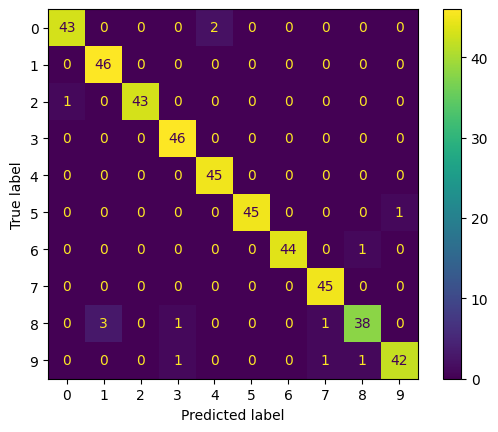

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()
plt.close()

# XGBOOST

In [10]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

scorer = make_scorer(f1_score, average='weighted')

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True), 
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'n_estimators': trial.suggest_int('n_estimators', 100, 800), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), 
        'gamma': trial.suggest_float('gamma', 0.0, 1.0), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True)  
    }

    model = XGBClassifier(**params, random_state=42, n_jobs=n_jobs)
    return cross_val_score(model, x_train, y_train, cv=5, scoring=scorer).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"Best CV Precision:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 176. Best value: 0.97184: 100%|██████████| 200/200 [18:58<00:00,  5.69s/it] 

Best CV Precision:  0.9718
Best params: {'learning_rate': 0.045344787705967206, 'max_depth': 5, 'n_estimators': 431, 'subsample': 0.9624309948099455, 'colsample_bytree': 0.6005117032951652, 'min_child_weight': 2, 'gamma': 0.0003929274276543663, 'reg_alpha': 0.22536719453957807, 'reg_lambda': 0.1750110161274079}


In [ ]:
from sklearn.metrics import classification_report

best_rf = XGBClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_rf.fit(x_train, y_train)
y_pred = best_rf.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.93      0.89      0.91        46
           2       1.00      1.00      1.00        44
           3       0.92      1.00      0.96        46
           4       0.94      1.00      0.97        45
           5       1.00      0.98      0.99        46
           6       1.00      0.98      0.99        45
           7       0.94      1.00      0.97        45
           8       0.93      0.86      0.89        43
           9       0.95      0.91      0.93        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



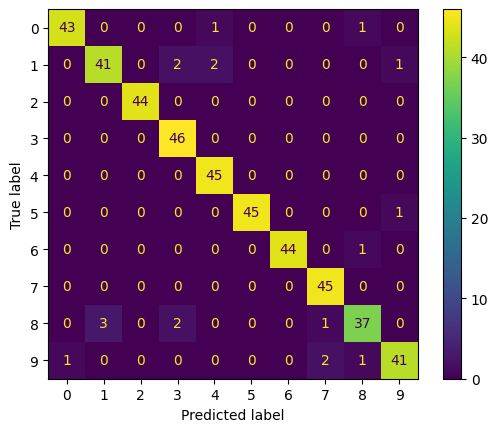

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()
plt.close()